In [7]:
import os
import pandas as pd


from edge_evaluations.lr_edge_evaluation import evaluate_lr_edge
from edge_evaluations.rf_edge_evalutaion import  evaluate_rf_edge
from edge_evaluations.xgb_edge_evaluation import evaluate_xgb_edge
from edge_evaluations.mlp_edge_evaluation import evaluate_mlp_edge
from edge_evaluations.lstm_edge_evaluation import evaluate_lstm_edge
from edge_evaluations.gru_edge_evaluation import evaluate_gru_edge
from edge_evaluations.bilstm_edge_evaluation import evaluate_bilstm_edge
from edge_evaluations.transformer_edge_evaluation import evaluate_transformer_edge
from edge_evaluations.cnn_lstm_edge_evaluation import evaluate_cnn_lstm_edge
from edge_evaluations.gnn_edge_evaluation import evaluate_gnn_edge

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [10]:
import numpy as np

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# SAFE + CLEAN UNIFIED RUNNER
# ==========================================================

def run_all_edge_metrics(input_dim=103):

    # -----------------------------
    # Define models + paths only
    # -----------------------------
    df_train = pd.read_csv("../outputs/datasets/train.csv")
    feature_cols = [c for c in df_train.columns 
                if c not in ["Perf_Avg_Throughput", "Perf_Avg_Latency", "Perf_Avg_Loss",
                             "StartDateTime", "EndDateTime", "Perf_Filename", 
                             "ND_Filename", "RunDateTime"]]

    # Create sample with correct feature names
    # X_sample = pd.DataFrame([np.random.randn(len(feature_cols))], columns=feature_cols)
    edge_jobs = {
        "LR": lambda: evaluate_lr_edge(
            model_path="../outputs/models/lr_model_throughput.pkl",
            scaler_path="../outputs/models/lr_scaler.pkl",
            input_dim=input_dim
        ),

        "RF": lambda: evaluate_rf_edge(
            model_path="../outputs/models/rf_model_throughput.pkl",
            X_sample= np.random.randn(1, 103)
        ),

        "XGB": lambda: evaluate_xgb_edge(
            model_path="../outputs/models/xgb_model_throughput.json",
            X_sample=pd.DataFrame([np.random.randn(len(feature_cols))], columns=feature_cols)
        ),

        "MLP": lambda: evaluate_mlp_edge(
            model_path="../outputs/models/mlp_model_throughput.pt",
            input_dim=input_dim
        ),

        "LSTM": lambda: evaluate_lstm_edge(
            model_path="../outputs/models/lstm_model_throughput.pt",
            input_dim=input_dim
        ),

        "GRU": lambda: evaluate_gru_edge(
            model_path="../outputs/models/gru_model_throughput.pt",
            input_dim=input_dim
        ),

        "BiLSTM": lambda: evaluate_bilstm_edge(
            model_path="../outputs/models/bilstm_model_throughput.pt",
            input_dim=input_dim
        ),

        "Transformer": lambda: evaluate_transformer_edge(
            model_path="../outputs/models/transformer_model_throughput.pt",
            input_dim=input_dim
        ),
        
        "CNN-LSTM": lambda: evaluate_cnn_lstm_edge(
            model_path="../outputs/models/cnn_lstm_model_throughput.pt",
            input_dim=input_dim
        ),
        "GNN": lambda: evaluate_gnn_edge(
            model_path="../outputs/models/gnn_model_throughput.pt",
            input_dim=3,
            num_nodes=10
        ),
    }

    # -----------------------------
    # Run models with tqdm
    # -----------------------------
    print("\n========== Running Unified Edge Evaluation ==========\n")

    results = {}

    pbar = tqdm(edge_jobs.items(), total=len(edge_jobs), unit="model")

    for model_name, eval_fn in pbar:
        pbar.set_description(f"Evaluating {model_name}")

        # run evaluation
        results[model_name] = eval_fn()

    # -----------------------------
    # Save results
    # -----------------------------
    df = pd.DataFrame(results).T
    out_dir = "../outputs/edge_analysis/"
    os.makedirs(out_dir, exist_ok=True)

    out_path = os.path.join(out_dir, "unified_edge_metrics.csv")
    df.to_csv(out_path)

    print(f"\nSaved unified edge evaluation → {out_path}")
    return df


# ==========================================================
# RUN
# ==========================================================
if __name__ == "__main__":
    run_all_edge_metrics()



========== Running Unified Edge Evaluation ==========



Evaluating LR:   0%|          | 0/10 [00:00<?, ?model/s]e:\AIT_Projects\NS3-Project\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
e:\AIT_Projects\NS3-Project\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Evaluating RF:   0%|          | 0/10 [00:00<?, ?model/s]

Evaluating GNN: 100%|██████████| 10/10 [00:16<00:00,  1.61s/model]       


Saved unified edge evaluation → ../outputs/edge_analysis/unified_edge_metrics.csv


In [11]:
df=pd.read_csv("../outputs/edge_analysis/unified_edge_metrics.csv", index_col=0)
df.head(10)

,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Model Path,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
LR,104.0,416.0,0.000397,206.0,0.000033,0.032709,1.030000e-07,4,../outputs/models/lr_model_throughput.pkl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RF,NaN,118129.0,0.112657,NaN,0.066986,66.985529,1.339711e-01,824,../outputs/models/rf_model_throughput.pkl,300.0,300.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
XGB,NaN,164547.0,0.156924,NaN,0.000558,0.558086,1.116172e-03,824,../outputs/models/xgb_model_throughput.json,400.0,400.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
MLP,21633.0,86532.0,0.082523,42880.0,0.000186,0.186454,3.729070e-04,4,../outputs/models/mlp_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSTM,76609.0,306436.0,0.292240,86144.0,0.000548,0.548116,1.096231e-03,4,../outputs/models/lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GRU,57473.0,229892.0,0.219242,64640.0,0.000338,0.337959,6.759170e-04,4,../outputs/models/gru_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BiLSTM,185985.0,743940.0,0.709476,172288.0,0.000864,0.864339,1.728679e-03,4,../outputs/models/bilstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transformer,409985.0,1639940.0,1.563969,393728.0,0.000634,0.634085,NaN,4,../outputs/models/transformer_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,0.001268,NaN,NaN,NaN
CNN-LSTM,53185.0,NaN,0.202885,106370.0,NaN,0.576969,1.153938e-03,4120,../outputs/models/cnn_lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GNN,1217.0,4868.0,0.004642,NaN,0.000929,0.928573,NaN,120,../outputs/models/gnn_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,0.004643,10.0,3.0,32.0


In [ ]:
df.describe()

,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Estimated Energy (J)
count,6.000000,8.000000e+00,8.000000,6.000000,8.000000,8.000000,7.000000e+00,8.000000,2.000000,2.000000,2.0,2.0,2.0,1.000000
mean,125298.166667,4.112290e+05,0.392179,126647.666667,0.008380,8.379569,1.897126e-02,209.000000,350.000000,350.000000,1.0,0.0,0.0,0.001222
std,153701.281156,5.457952e+05,0.520511,142762.011241,0.022500,22.500014,4.813369e-02,379.586241,70.710678,70.710678,0.0,0.0,0.0,NaN
min,104.000000,4.160000e+02,0.000397,206.000000,0.000026,0.026201,1.030000e-07,4.000000,300.000000,300.000000,1.0,0.0,0.0,0.001222
25%,30593.000000,1.102298e+05,0.105123,48320.000000,0.000266,0.265624,4.666920e-04,4.000000,325.000000,325.000000,1.0,0.0,0.0,0.001222
50%,67041.000000,1.972195e+05,0.188083,75392.000000,0.000520,0.520012,9.409080e-04,4.000000,350.000000,350.000000,1.0,0.0,0.0,0.001222
75%,158641.000000,4.158120e+05,0.396549,150752.000000,0.000666,0.666252,1.401598e-03,209.000000,375.000000,375.000000,1.0,0.0,0.0,0.001222
max,409985.000000,1.639940e+06,1.563969,393728.000000,0.064061,64.060617,1.281212e-01,824.000000,400.000000,400.000000,1.0,0.0,0.0,0.001222


In [12]:
print(df.columns.tolist())


['Parameters', 'Model Size (Bytes)', 'Model Size (MB)', 'FLOPs', 'Latency (s)', 'Latency (ms)', 'Energy Estimated (J)', 'Peak Activation Memory (Bytes)', 'Model Path', 'Trees', 'Total Nodes', 'Average Nodes per Tree', 'Average Tree Depth', 'Max Tree Depth', 'Estimated Energy (J)', 'Num Nodes', 'Node Feature Dim', 'Hidden Dim']


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# ===============================================================
# Load Unified Metrics
# ===============================================================

def load_metrics(csv_path="../outputs/edge_analysis/unified_edge_metrics.csv"):
    df = pd.read_csv(csv_path, index_col=0)

    # Validate required columns
    required = [
        "Model Size (MB)",
        "Latency (ms)",
        "Energy Estimated (J)",
        "FLOPs",
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}\nAvailable: {df.columns.tolist()}")

    return df



# ===============================================================
# 1. Model Size vs Latency
# ===============================================================

def plot_size_vs_latency(df, save_dir,showImage=False):
    plt.figure(figsize=(10, 6))

    plt.bar(df.index, df["Model Size (MB)"], alpha=0.6, label="Model Size (MB)")
    plt.plot(df.index, df["Latency (ms)"], color="red", marker="o", linewidth=2, label="Latency (ms)")

    plt.title("Model Size vs Inference Latency")
    plt.xlabel("Model")
    plt.ylabel("Value")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    path = os.path.join(save_dir, "size_vs_latency.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()



# ===============================================================
# 2. Energy per Inference
# ===============================================================

def plot_energy(df, save_dir, showImage=False):
    plt.figure(figsize=(10, 6))

    plt.bar(df.index, df["Energy Estimated (J)"], color="orange", alpha=0.7)

    plt.title("Energy per Inference (J)")
    plt.xlabel("Model")
    plt.ylabel("Energy (J)")
    plt.grid(True, linestyle="--", alpha=0.4)

    path = os.path.join(save_dir, "energy_per_inference.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()



# ===============================================================
# 3. FLOPs Comparison
# ===============================================================

def plot_flops(df, save_dir,showImage=False):
    plt.figure(figsize=(10, 6))

    plt.bar(df.index, df["FLOPs"], color="green", alpha=0.7)

    plt.title("Model FLOPs per Inference")
    plt.xlabel("Model")
    plt.ylabel("FLOPs")
    plt.grid(True, linestyle="--", alpha=0.4)

    path = os.path.join(save_dir, "flops_comparison.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()



# ===============================================================
# 4. Radar Chart (Normalized Multi-Metric Comparison)
# ===============================================================

def plot_radar(df, save_dir, showImage=False):

    metrics = ["Model Size (MB)", "Latency (ms)", "Energy Estimated (J)", "FLOPs"]
    labels = df.index.tolist()

    # normalization 0-1
    norm_df = (df[metrics] - df[metrics].min()) / (df[metrics].max() - df[metrics].min())

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for model in labels:
        values = norm_df.loc[model].tolist()
        values += values[:1]

        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    plt.title("Normalized Model Comparison (Radar Chart)")
    plt.legend(bbox_to_anchor=(1.2, 1.1))

    path = os.path.join(save_dir, "radar_comparison.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()



# ===============================================================
# 5. Latency–Energy Pareto Plot
# ===============================================================

# def plot_latency_energy(df, save_dir, showImage=False):
#     plt.figure(figsize=(10, 6))

#     x = df["Latency (ms)"]
#     y = df["Energy Estimated (J)"]
#     sizes = df["Model Size (MB)"] * 20

#     plt.scatter(x, y, s=sizes, alpha=0.7)

#     for model in df.index:
#         plt.text(x[model] + 0.5, y[model] + 0.0002, model, fontsize=9)

#     plt.title("Latency vs Energy per Inference (Bubble = Model Size)")
#     plt.xlabel("Latency (ms)")
#     plt.ylabel("Energy (J)")
#     plt.grid(True, linestyle="--", alpha=0.4)

#     path = os.path.join(save_dir, "latency_vs_energy.png")
#     plt.savefig(path, dpi=300, bbox_inches="tight")
#     if showImage:
#         plt.show()
#     plt.close()

def plot_latency_energy(df, save_dir, showImage=False):
    plt.figure(figsize=(10, 6))

    x = df["Latency (ms)"]
    y = df["Energy Estimated (J)"]
    sizes = df["Model Size (MB)"] * 25

    plt.scatter(x, y, s=sizes, alpha=0.75)

    for model in df.index:
        plt.annotate(
            model,
            (x[model], y[model]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    # -------------------------------
    # Log scaling (key improvement)
    # -------------------------------
    plt.xscale("log")
    plt.yscale("log")

    plt.title("Latency vs Energy per Inference (Bubble = Model Size)")
    plt.xlabel("Latency (ms, log scale)")
    plt.ylabel("Energy per Inference (J, log scale)")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)

    path = os.path.join(save_dir, "latency_vs_energy_log.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")

    if showImage:
        plt.show()
    plt.close()




# ===============================================================
# MAIN GENERATOR
# ===============================================================

def generate_edge_comparison_plots(showImage=False):
    save_dir = "../outputs/edge_analysis/plots/"
    os.makedirs(save_dir, exist_ok=True)

    df = load_metrics()

    plot_size_vs_latency(df, save_dir, showImage)
    plot_energy(df, save_dir, showImage)
    plot_flops(df, save_dir, showImage)
    plot_radar(df, save_dir, showImage)
    plot_latency_energy(df, save_dir, showImage)

    print("\n✔ All comparison plots generated successfully.")



# ===============================================================
# Run
# ===============================================================
if __name__ == "__main__":
    generate_edge_comparison_plots()



✔ All comparison plots generated successfully.


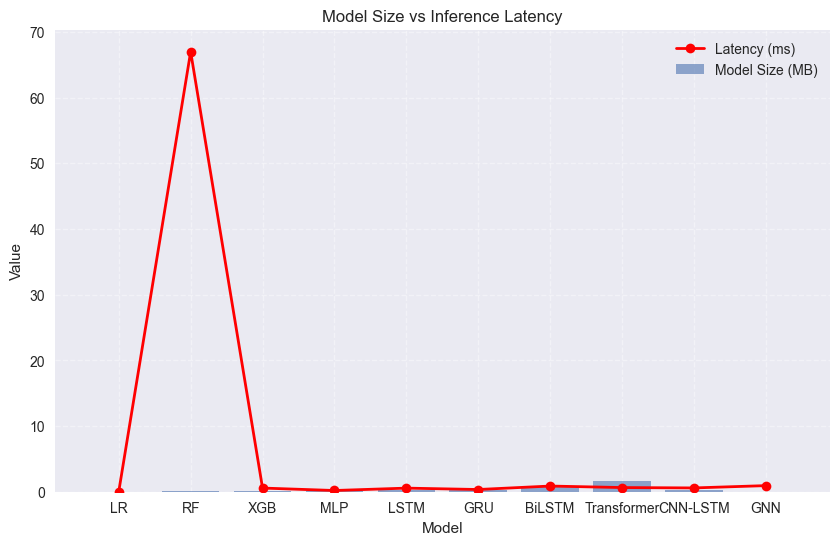

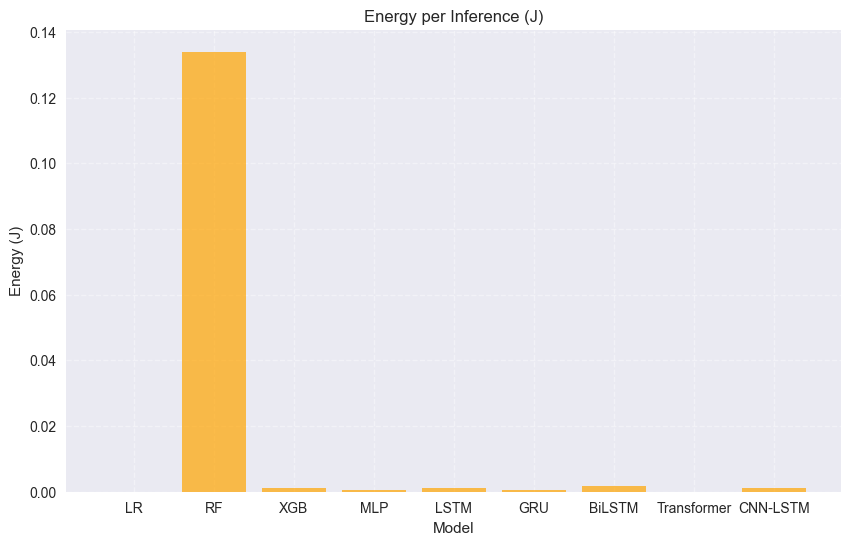

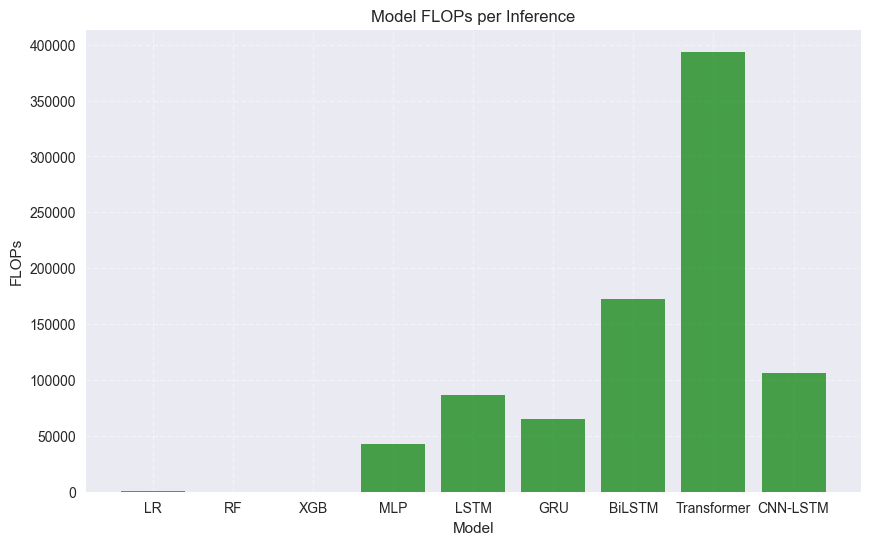

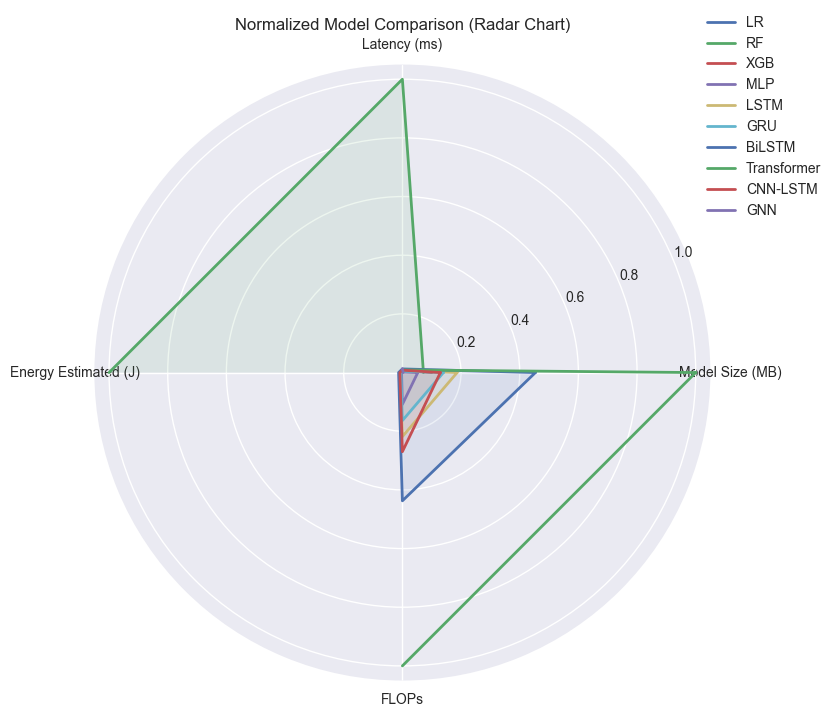

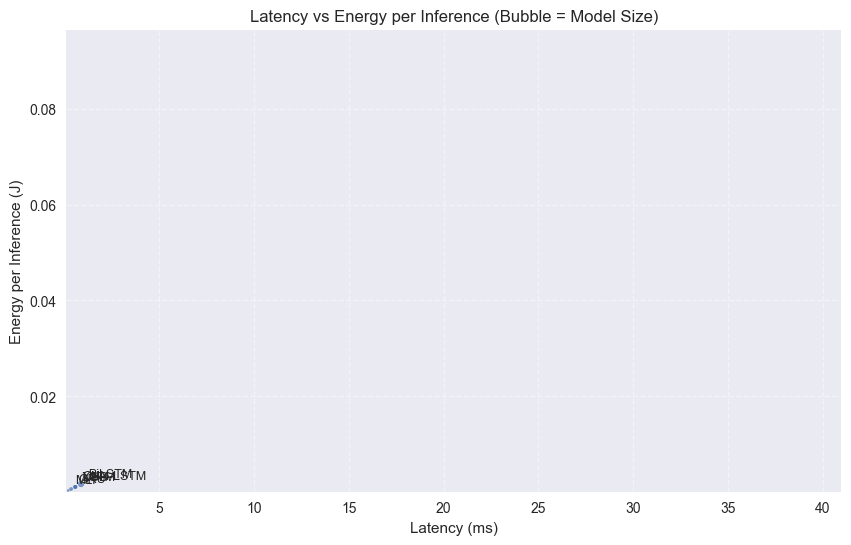


✔ All comparison plots generated successfully.


In [18]:
generate_edge_comparison_plots(showImage=True)